<a href="https://colab.research.google.com/github/leajag/2025_ML_EES/blob/main/final_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Common imports
import numpy as np
import matplotlib as plt
import pandas as pd
import os
import matplotlib.pyplot as plt

# Extra imports for data pre- processing
!pip install rasterio
import rasterio

!pip install geopandas
import geopandas as gpd

!pip install --upgrade pyshp

!pip install --upgrade shapely

!pip install --upgrade descartes

!pip install --upgrade rtree

from __future__ import print_function

from osgeo import ogr

#for CNN
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from keras.utils import plot_model
from sklearn.model_selection import train_test_split



In [70]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [71]:
!ls /content/drive/MyDrive

'Albedo img'	    GEEDiT_export_LJ.geojson  'notebooks glacier'
'Colab Notebooks'   ML_project		      'RGB img'


In [72]:
data = np.load("/content/drive/MyDrive/ML_project/data_arrays.npz")
X = data['X']
y = data['y']

In [73]:
y_labels = y[:, 0, 0]  # takes left upper pixel per image, to ensure, that all classes are in test set

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y_labels)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2880, 3, 128, 128)
X_test shape: (320, 3, 128, 128)
y_train shape: (2880, 128, 128)
y_test shape: (320, 128, 128)


In [74]:
y_train_labels = y_train[:,0,0]  # upper left pixel to adjust labels as for all pixels in one image same class
y_test_labels = y_test[:,0,0]

**k-fold Cross validation:**

In [75]:
from sklearn.model_selection import StratifiedKFold # Generate test sets such that all contain the same distribution of classes, or as close as possible.

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42) # 5-Fold Stratified Cross Validation


In [76]:
X_base_train, y_base_train = X_train, y_train # Preserve the original training sets

for fold, (train_index, val_index) in enumerate(kf.split(X_base_train, y_train_labels)):

    # Assign to new variables for each fold to avoid modifying the original X_train and y_train
    X_fold_train, X_fold_valid = X_base_train[train_index], X_base_train[val_index]
    y_fold_train, y_fold_valid = y_base_train[train_index], y_base_train[val_index]
    y_fold_train_labels = y_train_labels[train_index]
    y_fold_valid_labels = y_train_labels[val_index]



In [77]:
print(X_fold_train.shape)
print(y_fold_train.shape)


(2304, 3, 128, 128)
(2304, 128, 128)


In [78]:
#flatten layer for LR and RFC to 2D array
# Flatten X_fold_train from (samples, channels, height, width) to (samples, features)

X_train_2D = X_fold_train.reshape(X_fold_train.shape[0], -1)
y_train_2D = y_fold_train.reshape(y_fold_train.shape[0], -1)

X_test_2D = X_test.reshape(X_test.shape[0], -1)
y_test_2D = y_test.reshape(y_test.shape[0], -1)

print("X train", X_fold_train.shape)
print("y test", y_test.shape)

print( "X train 2D", X_train_2D.shape)
print("X test 2D", X_test_2D.shape)
print("y train 2D", y_train_2D.shape)
print("y test 2D", y_test_2D.shape)




X train (2304, 3, 128, 128)
y test (320, 128, 128)
X train 2D (2304, 49152)
X test 2D (320, 49152)
y train 2D (2304, 16384)
y test 2D (320, 16384)


**Logistic Regression:**

In [79]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(multi_class = "multinomial",max_iter=1000, random_state=42)
clf.fit(X_train_2D, y_fold_train_labels) #takes: 1:15min


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [80]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf_preds = clf.predict(X_test_2D)
clf_acc = accuracy_score(y_test_labels, clf_preds)
print("CLF accuracy score:", clf_acc)


CLF accuracy score: 0.609375


**Random Forest:**

In [81]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier()
rfc.fit(X_train_2D, y_fold_train_labels)

RandomForestClassifier()

In [82]:
rfc_preds = rfc.predict(X_test_2D)
rfc_acc = accuracy_score(y_test_labels, rfc_preds)
print("RF accuracy score:", rfc_acc)


RF accuracy score: 0.634375


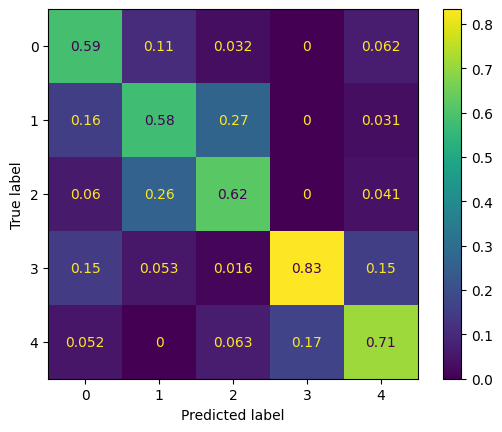

In [83]:
cm = confusion_matrix(y_test_labels, rfc_preds, normalize="pred") # Get a confusion matrix 'cm', use 'pred' for the normalize option
disp = ConfusionMatrixDisplay(confusion_matrix = cm) # Use ConfusionMatrixDisplay to visualize 'cm'
disp.plot()


**CNN:**
model1

In [116]:
# Reorganisation for Keras: transpose X_fold_train and X_fold_valid to (batch, height, width, channels)
X_fold_train_trans = np.transpose(X_fold_train, (0, 2, 3, 1))
X_fold_valid_trans = np.transpose(X_fold_valid, (0, 2, 3, 1))
X_test_trans = np.transpose(X_test, (0, 2, 3, 1))

In [117]:
model1 = tf.keras.Sequential()
input_img_shape = (X_train.shape[2], X_train.shape[3], X_train.shape[1]) #reorganisation of channels for Keras

In [118]:
#layers from 5.2 lab
#first layer: 16 filters, a 3x3 kernel size, a ReLU activation function and 'SAME' padding, weights are initialised by providing the input_shape argument in the first layer.
model1.add(tf.keras.layers.Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'))
model1.add(tf.keras.layers.Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'))
model1.add(MaxPooling2D((8,8),name='pool_1'))
model1.add(tf.keras.layers.Flatten(name='flatten'))
model1.add(tf.keras.layers.Dense(32, activation='relu',name='dense_1'))
model1.add(tf.keras.layers.Dense(10,activation='softmax',name='dense_2'))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 128, 128, 8)    │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │        65,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 67,506 (263.70 KB)

 Trainable params: 67,506 (263.70 KB)

 Non-trainable params: 0 (0.00 B)

In [119]:
model1.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [155]:
epochs = 15
history_model1 = model1.fit(X_fold_train_trans, y_fold_train_labels,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(X_fold_valid_trans, y_fold_valid_labels))

In [156]:
score_model1 = model1.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model1[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6880 - loss: 2.2399 
Test accuracy: 0.659


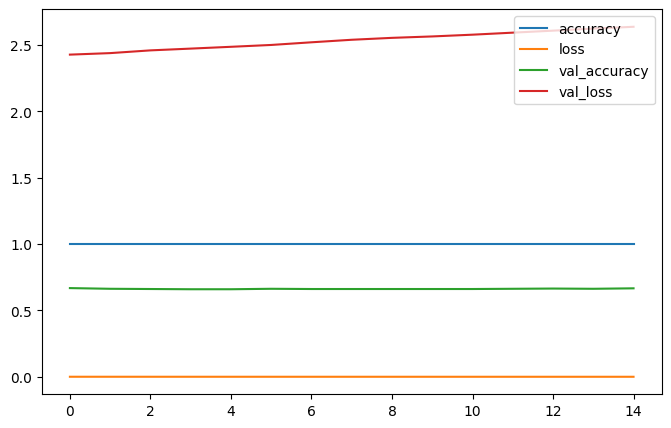

In [157]:
pd.DataFrame(history_model1.history).plot(figsize=(8,5))
plt.show()

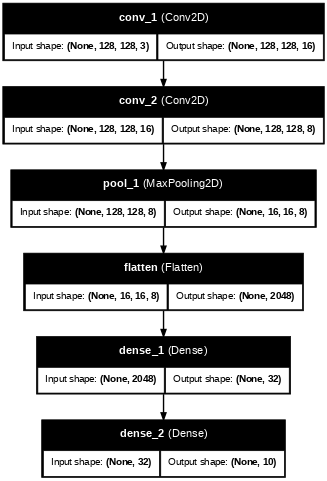

In [91]:
# Plot the model using Keras model plotting utilities
tf.keras.utils.plot_model(model1, show_shapes=True, show_layer_names=True, dpi=50 )

Implement callbacks to model1:

In [123]:
path_every = 'checkpoints_every_epoch/checkpoint_{epoch:03d}.weights.h5'
checkpoint_every_epoch = ModelCheckpoint(filepath=path_every,
                           save_freq="epoch",
                           save_weights_only=True,
                           monitor = "loss",
                           verbose=0)

In [124]:
path_best = 'checkpoints_best_only/checkpoint.weights.h5'
checkpoint_best_only = ModelCheckpoint(filepath=path_best,
                           save_freq="epoch",
                           save_weights_only=True,
                           save_best_only = True,
                           monitor = "val_accuracy",
                           verbose=1)

In [125]:
model = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])

model.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [141]:
callbacks = [checkpoint_every_epoch, checkpoint_best_only]

history_callback = model.fit(X_fold_train_trans, y_fold_train_labels,
                    epochs=15,
                    validation_data=(X_fold_valid_trans, y_fold_valid_labels),
                    callbacks = callbacks)

Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2478 - loss: 10.1351
Epoch 1: val_accuracy improved from -inf to 0.33333, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.2481 - loss: 10.0551 - val_accuracy: 0.3333 - val_loss: 1.5874
Epoch 2/40
70/72 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3912 - loss: 1.4824
Epoch 2: val_accuracy improved from 0.33333 to 0.48264, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3933 - loss: 1.4790 - val_accuracy: 0.4826 - val_loss: 1.3591
Epoch 3/40
67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5265 - loss: 1.1902
Epoch 3: val_accuracy improved from 0.48264 to 0.50694, saving model to checkpoints_best_only/checkpoint.weights.h5
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5274 - loss: 1.1869 - val_accuracy: 0.5069 - val_loss: 1.2054
Epoch 4/40
67/72 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step -

In [142]:
#new model using above structure
model_last_epoch = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])
model_last_epoch.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

# Load on the weights from the last training epoch.
model_last_epoch.load_weights("checkpoints_every_epoch/checkpoint_015.weights.h5")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [143]:
model_best_epoch = Sequential([
        Conv2D(16,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(8,(3,3),padding='SAME', activation='relu',name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(32, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])
model_best_epoch.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

# Load the weights leading to the highest validation accuracy.
model_best_epoch.load_weights('checkpoints_best_only/checkpoint.weights.h5')

In [144]:
#Verify that the validation accuarcy of the last and the best model.
score_model_last_epoch = model_last_epoch.evaluate(X_fold_valid_trans, y_fold_valid_labels) ###############accuracy: 0.68 same accuracy right?
print('Model validation accuracy with last epoch weights: {acc:0.3f}'.format(acc=score_model_last_epoch[1]))
print('')
score_model_best_epoch = model_best_epoch.evaluate(X_fold_valid_trans, y_fold_valid_labels) ################accuracy: 0.68
print('Model validation accuracy with best epoch weights: {acc:0.3f}'.format(acc=score_model_best_epoch[1]))

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5968 - loss: 1.6861
Model validation accuracy with last epoch weights: 0.639

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6437 - loss: 2.7022
Model validation accuracy with best epoch weights: 0.667


In [145]:
model_callback_best_epoch = model_best_epoch.evaluate(X_test_trans, y_test_labels)
print('Test accuracy - early stopping: {acc:0.3f}'.format(acc=model_callback_best_epoch[1]))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6280 - loss: 2.7380 
Test accuracy - early stopping: 0.584


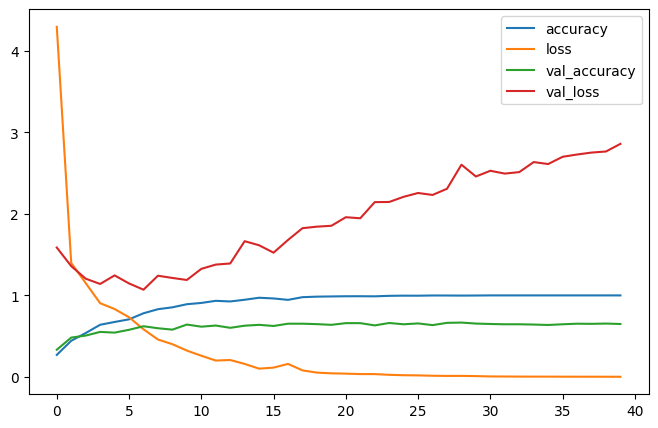

In [146]:
pd.DataFrame(history_callback.history).plot(figsize=(8,5))
plt.show()

Model 2 to improve model performance by trying to reduce the bias

In [151]:
#has the same structure as model1, but with more convolution units:
#conv_1 has 32 units, conv_2 has 64 units, dense_1 with 256 units

model2 = Sequential([
        Conv2D(32,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(64,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Flatten(name='flatten'),
        Dense(256, activation='relu',name='dense_1'),
        Dense(10,activation='softmax',name='dense_2')
    ])
model2.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [152]:
history_model2 = model2.fit(X_fold_train_trans, y_fold_train_labels,
                     epochs=15,
                     verbose = 0,
                     validation_data=(X_fold_valid_trans, y_fold_valid_labels))


In [153]:
score_model2 = model2.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model2[1])) #-> improved!

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6965 - loss: 1.8693
Test accuracy: 0.703


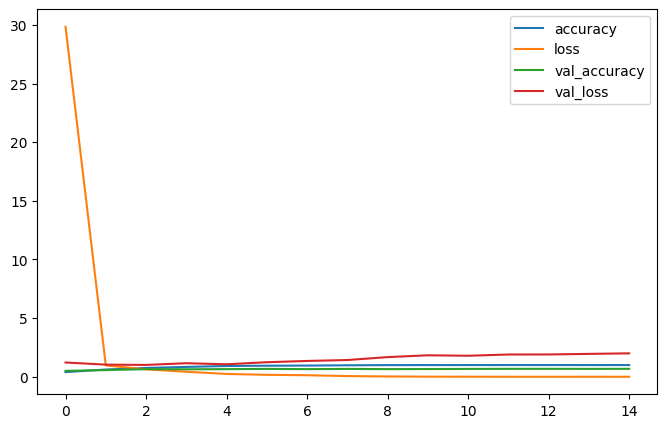

In [154]:
pd.DataFrame(history_model2.history).plot(figsize=(8,5))
plt.show()

Model 3 with reduced variance

In [130]:
#has the same structure as model2, but dropout layers one after the max pooling layer,
#one before the final dense layer with dropout rate of 0.2

model3 = Sequential([
        Conv2D(32,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_1'),
        Conv2D(64,(3,3),padding='SAME', activation='relu',input_shape=input_img_shape,name='conv_2'),
        MaxPooling2D((8,8),name='pool_1'),
        Dropout(rate = 0.2),
        Flatten(name='flatten'),
        Dense(256, activation='relu',name='dense_1'),
        Dropout(rate = 0.2),
        Dense(10,activation='softmax',name='dense_2')
    ])
model3.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [131]:
history_model3 = model3.fit(X_fold_train_trans, y_fold_train_labels,
                     epochs=15,
                     verbose = 0,
                     validation_data=(X_fold_valid_trans, y_fold_valid_labels))



Epoch 1/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.2930 - loss: 98.1299 - val_accuracy: 0.6267 - val_loss: 1.0423
Epoch 2/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5929 - loss: 0.9907 - val_accuracy: 0.6285 - val_loss: 0.8891
Epoch 3/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7106 - loss: 0.7351 - val_accuracy: 0.6806 - val_loss: 0.8634
Epoch 4/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.7652 - loss: 0.5895 - val_accuracy: 0.6719 - val_loss: 0.7805
Epoch 5/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8238 - loss: 0.4710 - val_accuracy: 0.7413 - val_loss: 0.7548
Epoch 6/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.8872 - loss: 0.3197 - val_accuracy: 0.7431 - val_loss: 0.7130
Epoch 7/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.9212 - loss: 0.2224 - val_accuracy: 0.6910 - val_loss: 0.9886
Epoch 8/40
72/72 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9333 - loss: 0.1955 - val_accuracy: 0.6927 -

In [132]:
score_model3 = model3.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model3[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6755 - loss: 1.7170
Test accuracy: 0.666


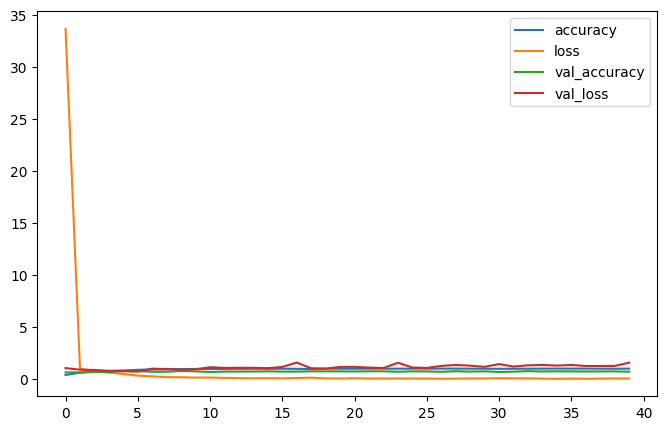

In [133]:
pd.DataFrame(history_model3.history).plot(figsize=(8,5))
plt.show()

Improve model with transfer learning:

In [147]:
from keras.applications import VGG16

conv_base = VGG16(include_top=False, input_shape = input_img_shape)
# freeze the weights
for layer in conv_base.layers:
    layer.trainable = False

model4 = Sequential([
        conv_base,
        Flatten(name='flatten'),
        Dropout(0.2),
        Dense(256, activation='relu',name='dense_1'),
        Dropout(0.2),
        Dense(10,activation='softmax',name='dense_2')
    ])
model4.compile(optimizer='adam',
                  loss = 'sparse_categorical_crossentropy',
                  metrics = ['accuracy'])

In [148]:
history_model4 = model4.fit(X_fold_train_trans, y_fold_train_labels, #takes 4min
                     epochs=15,
                     validation_data=(X_fold_valid_trans, y_fold_valid_labels))



Epoch 1/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 11s 99ms/step - accuracy: 0.4828 - loss: 4.5299 - val_accuracy: 0.6493 - val_loss: 0.9178
Epoch 2/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 77ms/step - accuracy: 0.7125 - loss: 0.7100 - val_accuracy: 0.7014 - val_loss: 0.8411
Epoch 3/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.8216 - loss: 0.4676 - val_accuracy: 0.7222 - val_loss: 0.7936
Epoch 4/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.8801 - loss: 0.3140 - val_accuracy: 0.7569 - val_loss: 0.7984
Epoch 5/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9062 - loss: 0.2481 - val_accuracy: 0.7622 - val_loss: 0.8260
Epoch 6/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 80ms/step - accuracy: 0.9118 - loss: 0.2218 - val_accuracy: 0.7708 - val_loss: 0.8127
Epoch 7/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9307 - loss: 0.1914 - val_accuracy: 0.7899 - val_loss: 0.7609
Epoch 8/15
72/72 ━━━━━━━━━━━━━━━━━━━━ 6s 79ms/step - accuracy: 0.9343 - loss: 0.1664 - val_accuracy: 0.7639 - 

In [149]:
score_model4 = model4.evaluate(X_test_trans, y_test_labels)
print('Test accuracy: {acc:0.3f}'.format(acc=score_model4[1]))

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.7946 - loss: 0.9672
Test accuracy: 0.762


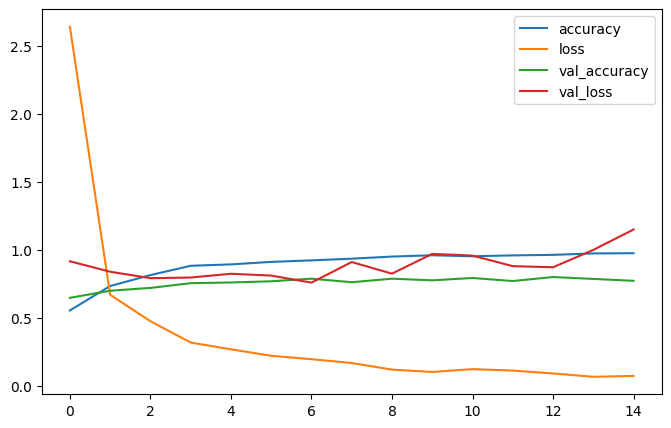

In [150]:
pd.DataFrame(history_model4.history).plot(figsize=(8,5))
plt.show()

In [138]:
#accuracy score comparison
print("CLF accuracy score:", clf_acc)
print("RF accuracy score:", rfc_acc)

print("CNN:")
print('Test accuracy model1: {acc:0.3f}'.format(acc=score_model1[1]))
print('')
print('Model validation accuracy with last epoch weights: {acc:0.3f}'.format(acc=score_model_last_epoch[1]))
print('')
print('Model validation accuracy with best epoch weights: {acc:0.3f}'.format(acc=score_model_best_epoch[1]))
print('')
print('Test accuracy model2 - reducing bias: {acc:0.3f}'.format(acc=score_model2[1]))
print('Test accuracy model3 - reducing variance: {acc:0.3f}'.format(acc=score_model3[1]))
print('Test accuracy model4 - transfer learning: {acc:0.3f}'.format(acc=score_model4[1]))



CLF accuracy score: 0.609375
RF accuracy score: 0.634375
CNN:
Test accuracy model1: 0.656

Model validation accuracy with last epoch weights: 0.637

Model validation accuracy with best epoch weights: 0.688

Test accuracy model2 - reducing bias: 0.656
Test accuracy model3 - reducing variance: 0.666
Test accuracy model4 - transfer learning: 0.762


In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

# Pfad zum Raster
raster_path = "/content/drive/MyDrive/ML_project/data/d/class1/aug_0_1_poly_91.tif"

# Raster laden
with rasterio.open(raster_path) as src:
    img = src.read()  # shape: (4, H, W)
    profile = src.profile

# RGB extrahieren (erste 3 Bänder)
rgb = img[:3, :, :]

# Rasterio liest als (B, H, W) → matplotlib erwartet (H, W, B)
rgb = np.moveaxis(rgb, 0, -1)

# Optional: Werte auf 0-255 strecken, falls Max < 255
for i in range(3):
    band = rgb[:, :, i]
    rgb[:, :, i] = ((band - band.min()) / (band.max() - band.min()) * 255).astype(np.uint8)

# Plot
plt.figure(figsize=(5, 5))
plt.imshow(rgb)
plt.title("aug_0_0_poly_25 - class1 / Region r")
plt.axis('off')
plt.show()


In [ ]:
#RandomizedSearchCV for hyperparameter search (RF) -> took too long
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

rfc = RandomForestClassifier(random_state=42)

param_dist = {
    'n_estimators': randint(100, 300),
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf': randint(2, 5),
    'max_features': ['sqrt']
}

random_search = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=param_dist,
    n_iter=10,        # 50 zufällige Kombinationen
    cv=3,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy',
    random_state=42
)

random_search.fit(X_train_2D, y_train_labels[train_index])
print("best parameters:",random_search.best_params_)
print("best score:", random_search.best_score_)

